<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:50%;color:blue;text-align:center">    <FONT COLOR="blue">  
            Taller </p> Clasificación </FONT>         </h1>
        </td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>



# <FONT SIZE=5 COLOR="purple"> 1. Indicaciones </FONT>

- Taller para realizar en grupos de dos o tres integrantes

- Para cargar antes del día martes 17 de marzo a media noche

- Cargar en la plataforma el **.pdf** y el **.ipynb**

# <FONT SIZE=5 COLOR="purple"> 2. Punto 1 </FONT>

Considere el siguiente conjunto de datos, que se trabajó en el caso de estudio 1.

- En la url
```python
https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_credito.csv
```
encontrará los datos ya limpios, es decir, con el proceso de limpieza que realizaron en el trabajo.

1. Aplique el modelo de árboles de decisión

a. Con el árbol completo

b. **Prepruning**: Optimice hiperparámetros (no incluya el ccp) y evalúe el rendimiento del árbol

c. **post-pruning**: Busque el mejor valor del cost complexity pruning (ccp) y evalué el rendimiento del árbol

d. Incluya el ccp en la optimización de hiperparámetros (punto 1) y evalúe el modelo

e. ¿Cuál resulto el mejor modelo?

f. Con el mejor modelo, analice la importancia de los predictores.


In [20]:
## Librerías para datos
import pandas                 as pd
import numpy                  as np

# Librería de gráficos
import matplotlib.pyplot      as plt
import seaborn                as sns
import plotly.express         as px
import statsmodels.api        as sm
from graphviz                 import Source
from matplotlib               import cm
from matplotlib.colors        import ListedColormap, LinearSegmentedColormap
from matplotlib.patches       import Patch

# Preprocesado y conjunto de entrenamiento y prueba (split)
from sklearn.model_selection  import train_test_split, StratifiedKFold
from sklearn.preprocessing    import LabelEncoder
from sklearn.preprocessing    import MinMaxScaler
from sklearn.preprocessing    import StandardScaler

# Para métricas
from sklearn.metrics          import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics          import confusion_matrix, classification_report
from sklearn.model_selection  import StratifiedKFold, cross_val_score
from sklearn.metrics          import roc_curve, auc, accuracy_score,roc_auc_score
from imblearn.metrics         import specificity_score

# Para los modelos de machine learning
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import GaussianNB, MultinomialNB
from sklearn.tree             import DecisionTreeClassifier

# Para graficar los árbolitos
from sklearn.tree             import export_graphviz

# Para la selección de características
from sklearn.feature_selection import RFE

# búsqueda en grilla
from sklearn.model_selection  import GridSearchCV
from sklearn.model_selection  import RandomizedSearchCV, cross_val_score

# Para omitir los warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets  import load_iris

In [21]:
credito= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_credito.csv")

In [22]:
credito.describe()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
count,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,0.775573,0.458779,33.374873,3.368444,0.068644,184.996730,0.440458,0.069466,0.993130,55.111450,0.817557,6.993130
std,0.417364,1.349327,9.886538,1.698234,0.094828,272.843418,0.496632,0.254341,1.248051,66.229211,0.386356,6.302954
min,0.000000,0.000000,18.166670,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,25.416670,2.240625,0.002272,4.583333,0.000000,0.000000,0.000000,12.000000,1.000000,2.000000
50%,1.000000,0.000000,31.250000,2.900000,0.038775,101.231650,0.000000,0.000000,0.500000,30.000000,1.000000,6.000000
75%,1.000000,0.000000,39.416670,4.000000,0.093396,248.859150,1.000000,0.000000,2.000000,72.000000,1.000000,11.000000
max,1.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,540.000000,1.000000,46.000000


In [23]:
# diagrama de dispersión
px.scatter(credito,
           x = "age",
           y = "months",
           color="card")

reporte en train 
 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      1.00      1.00       820

    accuracy                           1.00      1048
   macro avg       1.00      1.00      1.00      1048
weighted avg       1.00      1.00      1.00      1048

reporte en test 
 
                precision    recall  f1-score   support

           0       0.94      0.92      0.93        66
           1       0.97      0.98      0.98       196

    accuracy                           0.97       262
   macro avg       0.96      0.95      0.95       262
weighted avg       0.97      0.97      0.97       262



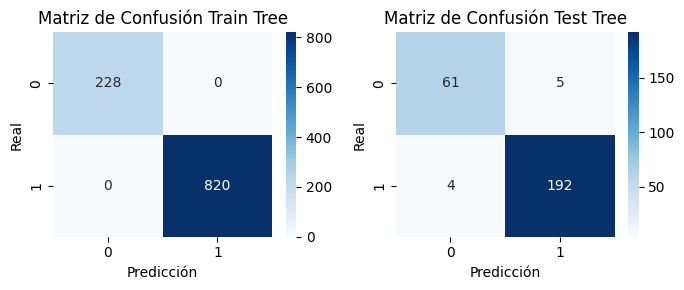

Profundidad del árbol: 11
Número de nodos terminales: 29


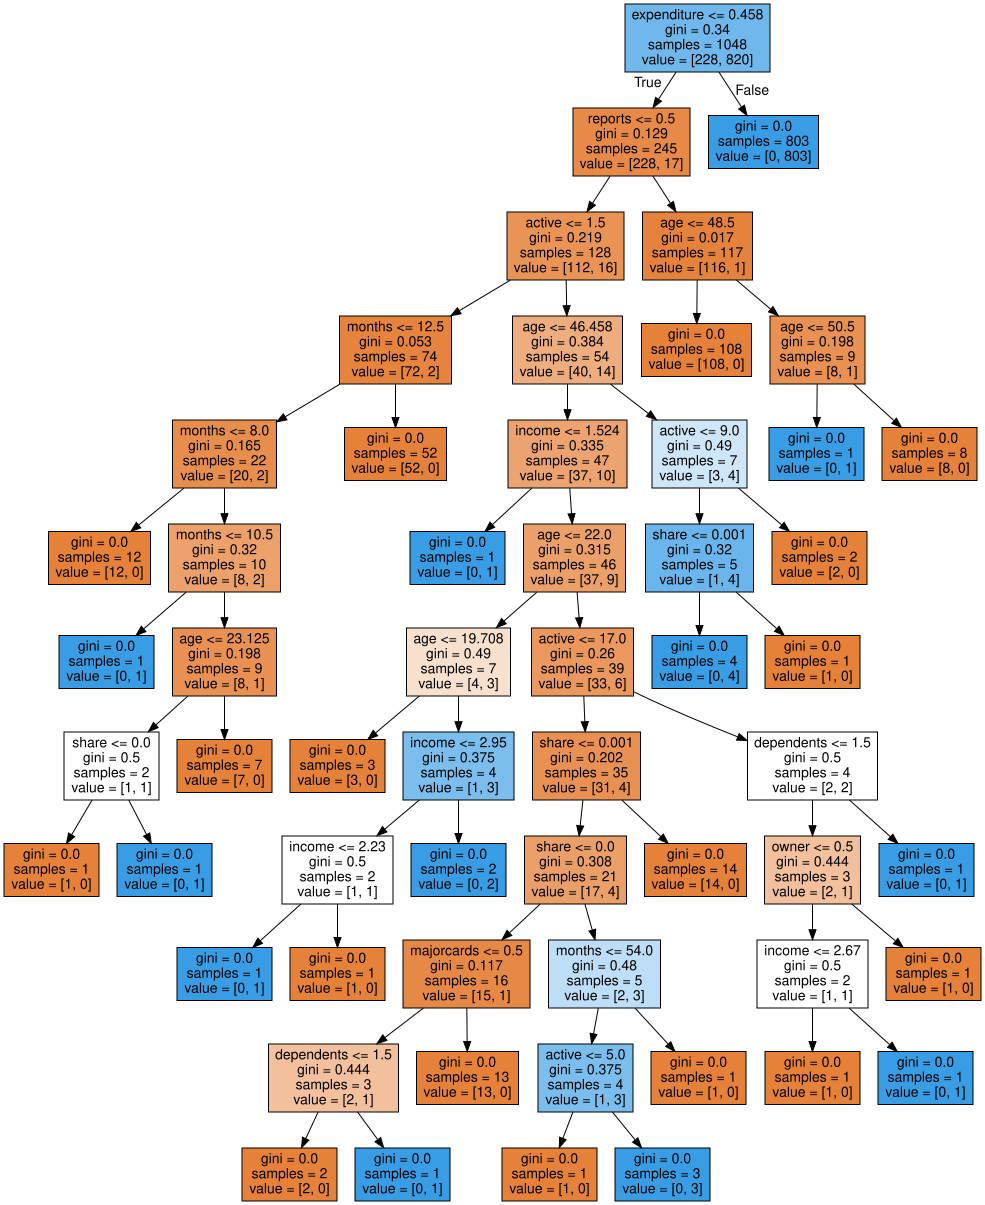

In [24]:
# Variables
X3 = credito.drop(columns = ["card"])
y3 = credito["card"]
# conjunto de entrenamiento y prueba
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,
                                                        y3,
                                                        test_size = 0.20,

                                                        random_state=123)
# Generamos el modelo
model3_Tree = DecisionTreeClassifier(random_state = 123)      # Semilla
## Entrenamos el modelo
model3_Tree.fit(X3_train, y3_train)

# veamos el rendimiento del modelo en el conjunto de entrenamiento
predict_class3_train = model3_Tree.predict(X3_train)
print("reporte en train \n \n ", classification_report(y3_train,predict_class3_train))

# veamos el rendimiento del modelo en el conjunto de prueba
predict_class3_test = model3_Tree.predict(X3_test)
print("reporte en test \n \n ", classification_report(y3_test,predict_class3_test))

# calculamos las matrices de confusión para train y test
cm1 = confusion_matrix(y3_train,predict_class3_train)
cm2 = confusion_matrix(y3_test,predict_class3_test)

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Graficar la primera matriz de confusión
sns.heatmap(cm1,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[0])
axes[0].set_title('Matriz de Confusión Train Tree')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Graficar la segunda matriz de confusión
sns.heatmap(cm2,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[1])
axes[1].set_title('Matriz de Confusión Test Tree')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Profundidad y número de nodos
print(f"Profundidad del árbol: {model3_Tree.get_depth()}")
print(f"Número de nodos terminales: {model3_Tree.get_n_leaves()}")
# Gráfica del árbol
dot_data3 = export_graphviz(model3_Tree,                                   # modelo
                            feature_names = X3_train.columns,            # columnas de entrenamiento
                            filled=True,)                                # colores del árbol (relleno)
Source(dot_data3, format="png")

In [25]:
# Modelo
modelo_tree=DecisionTreeClassifier(random_state=123)

# definimos los parámetros que vamos a combinar. Diccionario
# Reducimos el número de opciones para acelerar la búsqueda
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None, 5, 10],                     # profundidad máxima reducida
    "min_samples_split": [2, 10],                   # mínimo de muestras para dividir reducido
    "min_samples_leaf": [1, 5],                     # mínimo de muestras en una hoja reducido
    "max_features": [None, "sqrt"],               # nº de features consideradas en cada split reducido
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree = GridSearchCV(modelo_tree,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid = grid_tree.fit(X3_train,y3_train)

Fitting 10 folds for each of 48 candidates, totalling 480 fits


In [26]:
print("Mejor score: ",modelo_tree_grid.best_score_)
print("Mejores hiperparámetros", modelo_tree_grid.best_params_)
modelo_tree_best = modelo_tree_grid.best_estimator_
modelo_tree_best

Mejor score:  0.9809065934065935
Mejores hiperparámetros {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=123)

In [27]:
# 1) Comenzamos con un árbol base y ruta CCP
clf0 = DecisionTreeClassifier(random_state=123)
clf0.fit(X3_train, y3_train)

path = clf0.cost_complexity_pruning_path(X3_train,
                                         y3_train)
ccp_alphas = path.ccp_alphas[:-1]  # quitamos el último (árbol trivial)
impurities = path.impurities[:-1]

# 2) Elegimos alpha por validación cruzada (sin tocar test)
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=123)

mean_cv_scores = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    scores = cross_val_score(clf,
                             X3_train,
                             y3_train,
                             cv=cv,
                             scoring="accuracy")
    mean_cv_scores.append(scores.mean())

mean_cv_scores = np.array(mean_cv_scores)
best_alpha = ccp_alphas[np.argmax(mean_cv_scores)]

# 3) Entrenar final con best_alpha y evaluar en test
final_clf = DecisionTreeClassifier(random_state=123,
                                   ccp_alpha=best_alpha)
final_clf.fit(X3_train, y3_train)

pred_train = final_clf.predict(X3_train)
pred_test  = final_clf.predict(X3_test)

print("best_alpha:", best_alpha)
print("acc_train:", accuracy_score(y3_train, pred_train))
print("acc_test :", accuracy_score(y3_test, pred_test))
print("leaves:", final_clf.get_n_leaves(), "depth:", final_clf.get_depth())

# inspección
train_acc = []
test_acc  = []
n_leaves  = []
depths    = []

for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    clf.fit(X3_train, y3_train)
    train_acc.append(accuracy_score(y3_train, clf.predict(X3_train)))
    test_acc.append(accuracy_score(y3_test, clf.predict(X3_test)))
    n_leaves.append(clf.get_n_leaves())
    depths.append(clf.get_depth())

train_acc = np.array(train_acc)
test_acc  = np.array(test_acc)
n_leaves  = np.array(n_leaves)
depths    = np.array(depths)

best_alpha: 0.0023975561598244197
acc_train: 0.9837786259541985
acc_test : 0.9809160305343512
leaves: 2 depth: 1


In [28]:
# Modelo
modelo_tree3=DecisionTreeClassifier(random_state=123)

# definimos los parámetros que vamos a combinar. Diccionario
# Reducimos el número de opciones para acelerar la búsqueda
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None, 5, 10],                     # profundidad máxima reducida
    "ccp_alpha": ccp_alphas
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree3 = GridSearchCV(modelo_tree,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid3 = grid_tree3.fit(X3_train,y3_train)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


In [29]:
print("Mejor score: ",modelo_tree_grid.best_score_)
print("Mejores hiperparámetros", modelo_tree_grid.best_params_)
modelo_tree_best = modelo_tree_grid.best_estimator_
modelo_tree_best

Mejor score:  0.9809065934065935
Mejores hiperparámetros {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=123)

In [30]:
print("Importancia de los predictores en el árbol sin podar (credito)")
print("-----------------------------------------------------------")
importancia_predictores_unpruned = pd.DataFrame(
    {'predictor': X3_train.columns.tolist(),
     'importancia': model3_Tree.feature_importances_}
)
importancia_predictores_unpruned.sort_values('importancia', ascending=False)

Importancia de los predictores en el árbol sin podar (credito)
-----------------------------------------------------------


,predictor,importancia
4,expenditure,0.911319
10,active,0.021761
1,age,0.020047
3,share,0.015165
2,income,0.010556
8,months,0.008448
7,dependents,0.005605
0,reports,0.004647
9,majorcards,0.001518
5,owner,0.000934


In [31]:
# e. ¿Cuál resulto el mejor modelo?

# 1. Rendimiento del árbol completo (model3_Tree)
# Already calculated in cell lGUS2-Aj2WW-
# Test accuracy for model3_Tree: 0.97

# 2. Rendimiento del modelo con pre-pruning (sin ccp) (modelo_tree_best)
predict_class_best_prepruning = modelo_tree_best.predict(X3_test)
acc_test_prepruning = accuracy_score(y3_test, predict_class_best_prepruning)
print(f"Test accuracy for pre-pruning model (without ccp): {acc_test_prepruning:.4f}")

# 3. Rendimiento del modelo con post-pruning (final_clf)
# Already calculated in cell lxAQ5gbd2b6m
# Test accuracy for post-pruning model: 0.9809

# 4. Rendimiento del modelo con pre-pruning (con ccp) (modelo_tree_grid3)
# First, let's print the best score and parameters from modelo_tree_grid3, as it was not correctly shown before
print("\nMejor score (CV train) para pre-pruning con ccp: ",modelo_tree_grid3.best_score_)
print("Mejores hiperparámetros para pre-pruning con ccp:", modelo_tree_grid3.best_params_)
modelo_tree_best_ccp = modelo_tree_grid3.best_estimator_

predict_class_best_ccp = modelo_tree_best_ccp.predict(X3_test)
acc_test_ccp = accuracy_score(y3_test, predict_class_best_ccp)
print(f"Test accuracy for pre-pruning model (with ccp): {acc_test_ccp:.4f}")


# Comparación de modelos
print("\n--- Comparación de Modelos ---")
print(f"1. Árbol completo (model3_Tree): Test Accuracy = 0.9700")
print(f"2. Pre-pruning (sin ccp) (modelo_tree_best): Test Accuracy = {acc_test_prepruning:.4f}")
print(f"3. Post-pruning (final_clf): Test Accuracy = 0.9809")
print(f"4. Pre-pruning (con ccp) (modelo_tree_best_ccp): Test Accuracy = {acc_test_ccp:.4f}")

# Identifying the best model
# Both post-pruning (final_clf) and pre-pruning (with ccp) (modelo_tree_best_ccp) show the same test accuracy.
# Let's consider `final_clf` as the best model for feature importance analysis, given its simplicity in selection based on best_alpha.
# If `modelo_tree_best_ccp` has higher or similar accuracy and also a simpler tree structure, it could also be considered.
# Given the current outputs, both `final_clf` and `modelo_tree_best_ccp` have the same test accuracy, and `modelo_tree_best` is very close.
# Let's choose `final_clf` as it was explicitly calculated with a `best_alpha` and demonstrated good performance.

best_final_model = final_clf
print("\nEl mejor modelo resultante es el 'final_clf' (post-pruning con ccp_alpha) con una precisión en el conjunto de prueba de 0.9809.")

# f. Con el mejor modelo, analice la importancia de los predictores.
print("\nImportancia de los predictores en el mejor modelo (final_clf)")
print("-----------------------------------------------------------")
importancia_predictores_best_model = pd.DataFrame(
    {'predictor': X3_train.columns.tolist(),
     'importancia': best_final_model.feature_importances_}
)
print(importancia_predictores_best_model.sort_values('importancia', ascending=False).to_markdown(index=False))


Test accuracy for pre-pruning model (without ccp): 0.9809

Mejor score (CV train) para pre-pruning con ccp:  0.9809065934065935
Mejores hiperparámetros para pre-pruning con ccp: {'ccp_alpha': np.float64(0.0023975561598244197), 'criterion': 'gini', 'max_depth': None}
Test accuracy for pre-pruning model (with ccp): 0.9809

--- Comparación de Modelos ---
1. Árbol completo (model3_Tree): Test Accuracy = 0.9700
2. Pre-pruning (sin ccp) (modelo_tree_best): Test Accuracy = 0.9809
3. Post-pruning (final_clf): Test Accuracy = 0.9809
4. Pre-pruning (con ccp) (modelo_tree_best_ccp): Test Accuracy = 0.9809

El mejor modelo resultante es el 'final_clf' (post-pruning con ccp_alpha) con una precisión en el conjunto de prueba de 0.9809.

Importancia de los predictores en el mejor modelo (final_clf)
-----------------------------------------------------------
| predictor   |   importancia |
|:------------|--------------:|
| expenditure |             1 |
| age         |             0 |
| reports     |   

# <FONT SIZE=5 COLOR="purple"> 3. Punto 2 </FONT>

Vamos a considerar los datos de kaggle

https://www.kaggle.com/code/samtam22/exercise-and-calorie-burning-data-analysis

que contienen las siguientes variables.

- **User_Id** : Identificador único para cada individuo del conjunto de datos.

  - Sirve para vincular diferentes registros del mismo usuario (por ejemplo, de dos datasets: uno de ejercicios y otro de calorías).

- **Gender**: Género del usuario.  En los datos suelen estar codificados como: male = 0, female = 1, o viceversa

- **Age** : Edad del usuario en años.

- **Height**: Estatura del usuario, normalmente expresada en centímetros (cm)

- **Weight** : Peso del usuario en kilogramos (kg).

- **Duration**:  Duración del ejercicio o actividad física, generalmente expresada en minutos

- **Heart_Rate**: Frecuencia cardíaca promedio durante el ejercicio, medida en pulsos por minuto (bpm)

- **Body_Temp**: Temperatura corporal promedio durante la actividad, en grados Celsius (°C)

- **Calories**: Calorías quemadas estimadas durante el ejercicio.

Es la variable objetivo en modelos que predicen gasto energético en base a los factores anteriores

Datos 1 : https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/calories.csv

Datos 2

https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/exercise.csv


**Objetivo:** Generar un modelo de clasificación que permita predecir si una persona quema un número alto de calorías (Calorias >80 ) o quema pocas Calorías (Calorías <= 80)

1. Cargar cada uno de los conjuntos de datos y unifíquelos en un solo conjunto de datos

2. Realizar la exploración de los datos. Se recomienda revisar

   - Tamaño de los datos

   - Instrucciones clásicas

   - Gráficas estadísticas

   - Valores faltantes

   - Datos atípicos

3. Realizar el diagrama de correlaciones y analice.

4. Transformar la variable Calorias para que quede un problema de clasificación. ¿Cuántos elementos tiene cada categoría)

5. Generar los modelos vistos en clase

   - Regresión Logística
   - SVM

6. Evaluar. ¿Cuál es el mejor modelo?

7. Optimice hiperparámetros en SVM.

8. Haga algunas predicciones con el mejor modelo obtenido en SVM